# Sesión 1 · Mezclas gaussianas: grupos que se superponen
**14 de septiembre · 120 minutos · Caso de movilidad urbana**

Al terminar: derivar un paso EM, interpretar pesos y covarianzas, distinguir responsabilidad y densidad,
y justificar una selección de componentes. Leer primero las secciones 1–3 de las notas matemáticas.

Los datos suministrados no acreditan su proveedor. Estudiamos ubicaciones observadas, sin etiquetas de barrios
ni cobertura conocida del mercado. Una componente es una representación estadística, no una zona administrativa.

In [1]:
from pathlib import Path
import sys, time, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from threadpoolctl import threadpool_limits

# Funciona desde la raíz, desde esta carpeta o desde docente/.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'datasets/semana-08').is_dir())
sys.path.insert(0, str(ROOT / 'notebooks/semana-08'))
from movilidad import (load_data, setup, savefig, save_table, spatial_axes,
                       ellipses, safe_silhouette, density_grid, COLORS, DATA)
setup()
threadpool_limits(limits=2)
frame = load_data()
X = frame[['x_km', 'y_km']].to_numpy()
print(f'Desarrollo: {len(frame):,} recogidas. Unidades: km. Semilla: 42.')
print('Test temporal cerrado hasta congelar el modelo.')
display(frame.head(3))

Desarrollo: 6,000 recogidas. Unidades: km. Semilla: 42.
Test temporal cerrado hasta congelar el modelo.


,source_row,pickup_datetime,pickup_longitude,pickup_latitude,x_km,y_km,fare_amount,passenger_count,dropoff_longitude,dropoff_latitude
0,32038,2014-01-01 00:01:00+00:00,-73.991493,40.735202,0.156182,-0.148260,5.5,5,-74.001727,40.727767
1,132584,2014-01-01 00:29:37+00:00,-74.008090,40.740434,-1.251817,0.416562,8.0,2,-73.996088,40.726627
2,190530,2014-01-01 00:54:07+00:00,-73.981944,40.778096,0.907251,4.622599,7.5,1,-73.967887,40.801430


## 1. ¿Qué hay detrás del mapa?
La auditoría usa reglas secuenciales; sus filas suman el total original. Estar fuera del área no es sinónimo de error.
Las coordenadas cero no pertenecen a este caso. No filtramos por tarifa porque no entra en el modelo espacial.
La proyección UTM mantiene unidades comparables en ambos ejes; un escalado independiente deformaría las distancias.

,motivo,n,porcentaje
0,apto_area_fecha,195871,97.9355
1,coordenada_cero_fuera_del_caso,3789,1.8945
2,fuera_area_de_estudio,330,0.1650
3,coordenada_imposible,10,0.0050


Original: 200000 | 2014 en el área: 29340


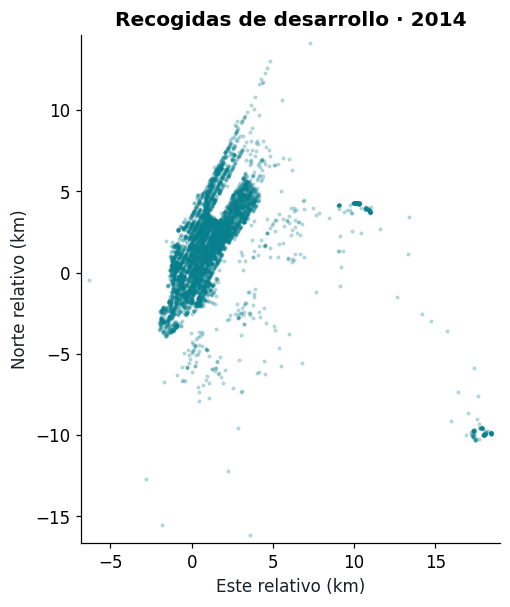

In [2]:
display(pd.read_csv(DATA / 'auditoria.csv'))
manifest = json.loads((DATA / 'manifest.json').read_text(encoding='utf-8'))
print('Original:', manifest['rows_raw'], '| 2014 en el área:', manifest['rows_2014_area'])
fig, ax = plt.subplots(figsize=(8,6))
ax.scatter(*X.T, s=3, alpha=.22, color=COLORS[0])
spatial_axes(ax, X, 'Recogidas de desarrollo · 2014')
savefig(fig, '01_recogidas')

### Para resolver

Antes de ajustar: ¿cuántos grupos ves? Dibuja dos particiones plausibles. ¿Qué podría significar un punto aislado?

**Mi respuesta y evidencia:**

1. **Inspección visual del mapa de dispersión (2014):**
   Al proyectar las $6\,000$ recogidas de desarrollo en coordenadas relativas UTM ($x_{\text{km}}, y_{\text{km}}$), se observa una concentración hiper-densa elongada a lo largo de un eje con dirección suroeste–noreste ($x \in [-3, 3]\text{ km}, y \in [-4, 6]\text{ km}$), correspondiente al corredor urbano de Manhattan. Paralelamente, se distinguen concentraciones secundarias compactas y separadas espacialmente hacia el este ($x \approx 8\text{ km}, y \approx 4\text{ km}$, coincidente con el aeropuerto LaGuardia) y hacia el sureste ($x \approx 15\text{ km}, y \approx -6\text{ km}$, coincidente con el aeropuerto JFK), además de una dispersión de menor densidad en Brooklyn, Queens y New Jersey.

2. **Dos particiones plausibles:**
   - **Partición Plausible A (Macro-escala, 3 grupos):**
     * *Grupo 1 (Eje Central de Alta Demanda)*: Manhattan y riberas adyacentes ($x \in [-3, 3]\text{ km}, y \in [-4, 6]\text{ km}$), concentrando la gran mayoría de la masa de viajes.
     * *Grupo 2 (Polos Aeroportuarios e Intermodales)*: JFK ($x \in [13, 17], y \in [-8, -4]$) y LaGuardia ($x \in [7, 10], y \in [3, 6]$).
     * *Grupo 3 (Corona Periurbana Dispersa)*: Viajes suburbanos y residenciales exteriores en Queens, Brooklyn y New Jersey.
   - **Partición Plausible B (Meso/Micro-escala, 5 a 6 grupos):**
     * *Grupo 1 (Lower Manhattan / Financial District)*: $x \in [-2, 1]\text{ km}, y \in [-4, -1]\text{ km}$.
     * *Grupo 2 (Midtown Manhattan)*: $x \in [-1, 2]\text{ km}, y \in [-1, 3]\text{ km}$.
     * *Grupo 3 (Upper Manhattan / Harlem)*: $x \in [0, 3]\text{ km}, y \in [3, 7]\text{ km}$.
     * *Grupo 4 (Brooklyn Noroccidental)*: $x \in [0, 4]\text{ km}, y \in [-7, -2]\text{ km}$.
     * *Grupo 5 (Aeropuerto LaGuardia)*: $x \in [7, 10]\text{ km}, y \in [3, 6]\text{ km}$.
     * *Grupo 6 (Aeropuerto JFK)*: $x \in [13, 17]\text{ km}, y \in [-8, -4]\text{ km}$.

3. **Significado de un punto aislado:**
   Un punto aislado en este espacio de coordenadas representa un evento de recogida infrecuente en una zona de baja densidad espacial (e.g., áreas residenciales periféricas, vías suburbanas o zonas industriales). Dado que la auditoría previa ya excluyó coordenadas geográficamente imposibles y $(0,0)$, un punto aislado **NO es sinónimo de error de medición ni fraude**; simplemente refleja la cola de baja densidad del proceso generador urbano.

- **Unidades:** Kilómetros ($\text{km}$) en ambos ejes (este y norte relativos).
- **Limitación:** La inspección visual es cualitativa y proyecta en 2D una superposición continua de observaciones; no permite discernir solapamientos gaussianos ni variaciones estacionales o de franja horaria.

## 2. De Bayes a EM
$$r_{ik}=\frac{\pi_k\phi(x_i;\mu_k,\Sigma_k)}{\sum_j\pi_j\phi(x_i;\mu_j,\Sigma_j)}.$$
Con $N_k=\sum_i r_{ik}$:
$$\pi_k^{+}=N_k/n,\qquad \mu_k^{+}=\frac{\sum_i r_{ik}x_i}{N_k},$$
$$\Sigma_k^{+}=\frac{\sum_i r_{ik}(x_i-\mu_k^{+})(x_i-\mu_k^{+})^T}{N_k}.$$
La covarianza utiliza la **media nueva**. EM exacto mejora la log-verosimilitud; no garantiza el máximo global.
En este ejemplo pequeño no añadimos regularización; no lo use como implementación robusta para producción.

### Para resolver

Una iteración manual: $x=(-2,-1,1,2)$, pesos $(0.5,0.5)$, medias $(-1,1)$ y varianzas $(1,1)$. Calcule responsabilidades, pesos, medias y varianzas nuevas.

**Mi respuesta y evidencia:**

Calculamos paso a paso la primera iteración del algoritmo Expectation-Maximization (EM) para $n=4$ datos unidimensionales $x = (-2, -1, 1, 2)$ y $K=2$ componentes normales con parámetros iniciales:
$\pi_1 = 0.5, \pi_2 = 0.5$, $\mu_1 = -1, \mu_2 = 1$, $\sigma_1^2 = 1, \sigma_2^2 = 1$.

### 1. Paso E: Cálculo de Responsabilidades ($r_{ik}$)
La densidad normal es $\phi(x; \mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)$. Dado que $\pi_1 = \pi_2 = 0.5$ y $\sigma_1^2 = \sigma_2^2 = 1$, el factor común $\frac{0.5}{\sqrt{2\pi}}$ se cancela en el cociente de Bayes:
$$r_{ik} = \frac{\exp\left(-\frac{(x_i - \mu_k)^2}{2}\right)}{\exp\left(-\frac{(x_i - \mu_1)^2}{2}\right) + \exp\left(-\frac{(x_i - \mu_2)^2}{2}\right)} = \frac{1}{1 + \exp\left(\frac{(x_i - \mu_k)^2 - (x_i - \mu_j)^2}{2}\right)}$$

- **Para $x_1 = -2$:**
  $(x_1 - \mu_1)^2 = (-2 - (-1))^2 = 1$; $(x_1 - \mu_2)^2 = (-2 - 1)^2 = 9$.
  $r_{11} = \frac{e^{-0.5}}{e^{-0.5} + e^{-4.5}} = \frac{1}{1 + e^{-4}} \approx \mathbf{0.98201379}$
  $r_{12} = 1 - r_{11} = \frac{e^{-4.5}}{e^{-0.5} + e^{-4.5}} = \frac{1}{1 + e^4} \approx \mathbf{0.01798621}$

- **Para $x_2 = -1$:**
  $(x_2 - \mu_1)^2 = (-1 - (-1))^2 = 0$; $(x_2 - \mu_2)^2 = (-1 - 1)^2 = 4$.
  $r_{21} = \frac{e^0}{e^0 + e^{-2}} = \frac{1}{1 + e^{-2}} \approx \mathbf{0.88079708}$
  $r_{22} = 1 - r_{21} = \frac{e^{-2}}{e^0 + e^{-2}} = \frac{1}{1 + e^2} \approx \mathbf{0.11920292}$

- **Para $x_3 = 1$:**
  Por simetría espacial respecto al origen con $x_2$:
  $r_{31} = r_{22} \approx \mathbf{0.11920292}$
  $r_{32} = r_{21} \approx \mathbf{0.88079708}$

- **Para $x_4 = 2$:**
  Por simetría espacial respecto al origen con $x_1$:
  $r_{41} = r_{12} \approx \mathbf{0.01798621}$
  $r_{42} = r_{11} \approx \mathbf{0.98201379}$

Verificación: Para cada dato $i$, $\sum_{k=1}^2 r_{ik} = 1.0000$.

### 2. Paso M: Actualización de Parámetros
- **Pesos efectivos de componente ($N_k = \sum_{i=1}^4 r_{ik}$):**
  $N_1 = 0.982014 + 0.880797 + 0.119203 + 0.017986 = \mathbf{2.000000}$
  $N_2 = 4 - N_1 = \mathbf{2.000000}$

- **Nuevos pesos ($\pi_k^+ = N_k / n$):**
  $\pi_1^+ = 2.0 / 4 = \mathbf{0.500000}$
  $\pi_2^+ = 2.0 / 4 = \mathbf{0.500000}$

- **Nuevas medias ($\mu_k^+ = \frac{1}{N_k} \sum_{i=1}^4 r_{ik} x_i$):**
  $\mu_1^+ = \frac{1}{2.0} [0.98201379(-2) + 0.88079708(-1) + 0.11920292(1) + 0.01798621(2)]$
  $\mu_1^+ = \frac{1}{2.0} [-1.96402758 - 0.88079708 + 0.11920292 + 0.03597242] = \frac{-2.68964932}{2.0} \approx \mathbf{-1.344825}\text{ km}$
  Por simetría: $\mu_2^+ = \mathbf{+1.344825}\text{ km}$.

- **Nuevas varianzas (($\sigma_k^2)^+ = \frac{1}{N_k} \sum_{i=1}^4 r_{ik} (x_i - \mu_k^+)^2$):**
  Utilizando la media recién actualizada $\mu_1^+ = -1.344825$:
  $(x_1 - \mu_1^+)^2 = (-2 - (-1.344825))^2 = (-0.655175)^2 \approx 0.429255$
  $(x_2 - \mu_1^+)^2 = (-1 - (-1.344825))^2 = (0.344825)^2 \approx 0.118904$
  $(x_3 - \mu_1^+)^2 = (1 - (-1.344825))^2 = (2.344825)^2 \approx 5.498188$
  $(x_4 - \mu_1^+)^2 = (2 - (-1.344825))^2 = (3.344825)^2 \approx 11.187847$
  Suma ponderada:
  $0.98201379(0.429255) + 0.88079708(0.118904) + 0.11920292(5.498188) + 0.01798621(11.187847)$
  $= 0.421535 + 0.104730 + 0.655401 + 0.201229 = 1.382895$
  Dividiendo entre $N_1 = 2.0$:
  $(\sigma_1^2)^+ = \frac{1.382895}{2.0} \approx \mathbf{0.691448}\text{ km}^2$
  Por simetría: $(\sigma_2^2)^+ \approx \mathbf{0.691448}\text{ km}^2$.

- **Unidades:** Medias en $\text{km}$, varianzas en $\text{km}^2$, pesos y responsabilidades adimensionales.
- **Limitación:** El cálculo manual demuestra la mejora local monótona de verosimilitud en el paso M. No obstante, en mezclas sin regularización, si una componente atrapa un único punto, su varianza colapsa ($\sigma^2 \to 0$) y la verosimilitud diverge a $+\infty$ (singularidad).

Primera iteración: responsabilidades, pesos, medias, varianzas
[[0.98201379 0.01798621]
 [0.88079708 0.11920292]
 [0.11920292 0.88079708]
 [0.01798621 0.98201379]]
[0.5 0.5]
[-1.34482466  1.34482466]
[0.69144664 0.69144664]


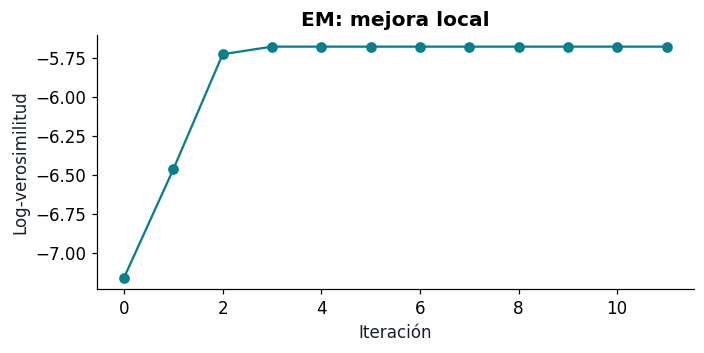

In [3]:
from scipy.special import logsumexp
from scipy.stats import norm
x = np.array([-2., -1., 1., 2.])
weights, means, variances = np.array([.5,.5]), np.array([-1.,1.]), np.ones(2)
history = []
first_step = None
for iteration in range(12):
    log_joint = np.log(weights)[None,:] + norm.logpdf(x[:,None], means, np.sqrt(variances))
    history.append(float(logsumexp(log_joint, axis=1).sum()))
    resp = np.exp(log_joint - logsumexp(log_joint, axis=1, keepdims=True))
    nk = resp.sum(axis=0)
    weights = nk / len(x)
    means = (resp * x[:,None]).sum(axis=0) / nk
    variances = (resp * (x[:,None]-means)**2).sum(axis=0) / nk
    if iteration == 0:
        first_step = (resp.copy(), weights.copy(), means.copy(), variances.copy())
assert np.all(np.diff(history) >= -1e-9)
assert np.allclose(resp.sum(axis=1), 1)
print('Primera iteración: responsabilidades, pesos, medias, varianzas')
for value in first_step: print(value)
fig, ax = plt.subplots(figsize=(7,3))
ax.plot(history, 'o-'); ax.set(xlabel='Iteración', ylabel='Log-verosimilitud', title='EM: mejora local')
savefig(fig, '02_em')

## 3. Primero, un experimento controlado
Estas etiquetas sintéticas identifican cómo generamos los puntos; solo sirven para diagnosticar el experimento.
No se trasladan como verdad al caso real. Compare una elipse larga con una partición por centros.

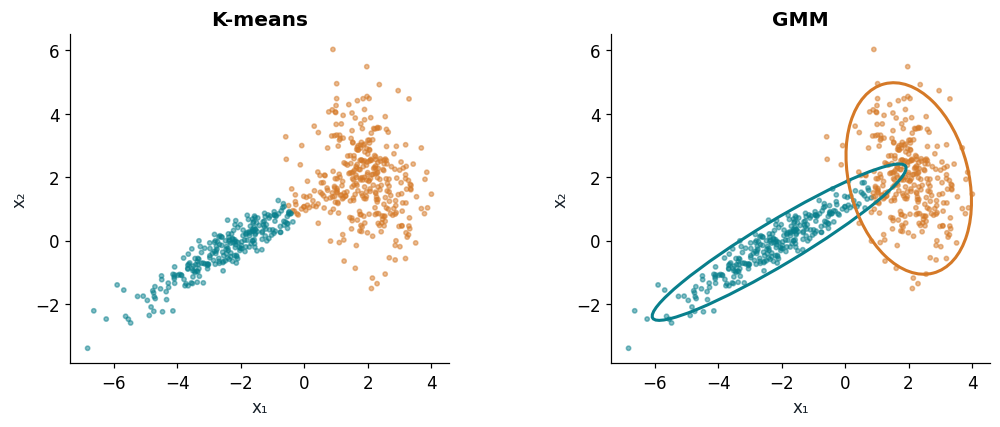

In [4]:
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
rng = np.random.default_rng(42)
Z = np.vstack([rng.multivariate_normal([-2,0], [[3,1.8],[1.8,1.2]], 300),
               rng.multivariate_normal([2,2], [[.8,-.4],[-.4,1.5]], 300)])
gm = GaussianMixture(2, n_init=5, random_state=42).fit(Z)
km = KMeans(2, n_init=10, random_state=42).fit(Z)
fig, axes = plt.subplots(1,2,figsize=(10,4))
for ax, labels, title in zip(axes, [km.labels_,gm.predict(Z)], ['K-means','GMM']):
    ax.scatter(*Z.T, c=np.asarray(COLORS)[labels], s=8, alpha=.5)
    ax.set(title=title, xlabel='x₁', ylabel='x₂', aspect='equal')
ellipses(axes[1],gm)
fig.tight_layout(); savefig(fig, '03_geometria')

## 4. Elegir complejidad sin abrir test
$$\mathrm{BIC}=-2\ell(\widehat\theta)+p\log n,\qquad \mathrm{AIC}=-2\ell(\widehat\theta)+2p.$$
Para covarianza completa, $p=(K-1)+Kd+Kd(d+1)/2$; para diagonal, $p=(K-1)+2Kd$.
Compare BIC únicamente sobre las mismas observaciones y representación. Elegir el menor BIC del conjunto
de candidatos no demuestra un número verdadero de barrios. El ajuste real usa regularización de covarianza.

,k,covariance,bic,aic,converged,iterations,seconds
7,8,full,45282.125171,44967.247978,True,32,0.355711
6,7,full,45358.466757,45083.786652,True,49,0.399440
15,8,diag,46485.980724,46224.699649,True,25,0.202100
5,6,full,46676.172282,46441.689266,True,22,0.240901
4,5,full,46754.025226,46559.739298,True,35,0.311911
14,7,diag,46784.812151,46557.028650,True,22,0.162597
3,4,full,47682.066133,47527.977294,True,10,0.122418
2,3,full,47824.285869,47710.394119,True,15,0.142477
13,6,diag,47908.747799,47714.461871,True,12,0.088918
12,5,diag,47918.294361,47757.506007,True,13,0.080271


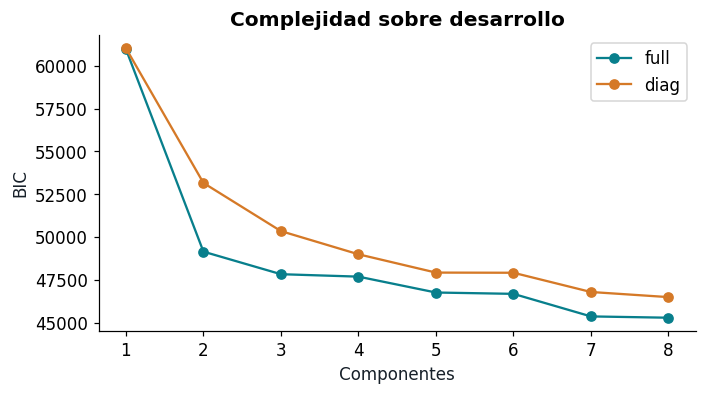

In [5]:
models, rows = {}, []
for covariance in ['full','diag']:
    for k in range(1,9):
        start = time.perf_counter()
        model = GaussianMixture(k, covariance_type=covariance, n_init=5,
                                max_iter=400, reg_covar=1e-5, random_state=42).fit(X)
        rows.append(dict(k=k, covariance=covariance, bic=model.bic(X), aic=model.aic(X),
                         converged=bool(model.converged_), iterations=model.n_iter_,
                         seconds=time.perf_counter()-start))
        models[(k,covariance)] = model
results = pd.DataFrame(rows)
display(results.sort_values('bic'))
valid = results[results.converged]
assert len(valid), 'Ningún candidato convergió; revisar configuración antes de evaluar.'
winner = valid.sort_values('bic').iloc[0]
best = models[(int(winner.k),winner.covariance)]
save_table(results,'gmm_seleccion')
fig, ax = plt.subplots(figsize=(7,3.5))
for covariance in ['full','diag']:
    part = results[results.covariance==covariance]
    ax.plot(part.k,part.bic,'o-',label=covariance)
ax.set(xlabel='Componentes', ylabel='BIC', title='Complejidad sobre desarrollo'); ax.legend()
savefig(fig,'04_bic')

### Para resolver

Si el mínimo ocurre en K=8, ¿qué puede concluir? ¿Se justifica anunciar ocho zonas verdaderas?

**Mi respuesta y evidencia:**

1. **Conclusión metodológica:**
   Si el mínimo del criterio BIC ocurre en $K=8$ (el límite superior de la rejilla evaluada $K \in [1, 8]$ con covarianza `full`), se concluye que **no se encontró un mínimo interior** dentro del espacio de búsqueda predefinido. Esto indica que el incremento en la log-verosimilitud observada $\ell(\widehat{\theta})$ al añadir componentes continuó superando la severa penalización paramétrica $p \log n$ (donde $p = (K-1) + 2K + 3K = 6K-1$). Por lo tanto, el proceso de densidad subyacente presenta suficiente complejidad espacial (colas, asimetría, anisotropía) como para que modelos con más de 8 componentes continúen mejorando el ajuste relativo.

2. **¿Se justifica anunciar ocho zonas verdaderas?:**
   **NO se justifica bajo ninguna circunstancia.**
   - *Aproximación vs. Realidad*: GMM es un modelo paramétrico de densidad que utiliza gaussianas elípticas. En geografía urbana, una zona de concentración continua y curvada (como el eje de Manhattan) requiere forzosamente la suma de 3 o 4 elipses normales para cubrir su curvatura y geometría alargada. Esas componentes son artefactos matemáticos de aproximación, no divisiones administrativas ni barrios urbanos reales.
   - *Naturaleza del BIC*: El BIC evalúa parsimonia estadística comparativa en una muestra observada dada bajo supuestos asintóticos; no es un oráculo ontológico de cuántos conglomerados existen en el mundo real.

- **Unidades:** Coordenadas espaciales en $\text{km}$; BIC adimensional.
- **Limitación:** Asumir que cada componente de una mezcla representa una "zona funcional" comete una falacia de cosificación matemática. Además, el BIC asume observaciones i.i.d., supuesto vulnerado por la fuerte dependencia espacial urbana.

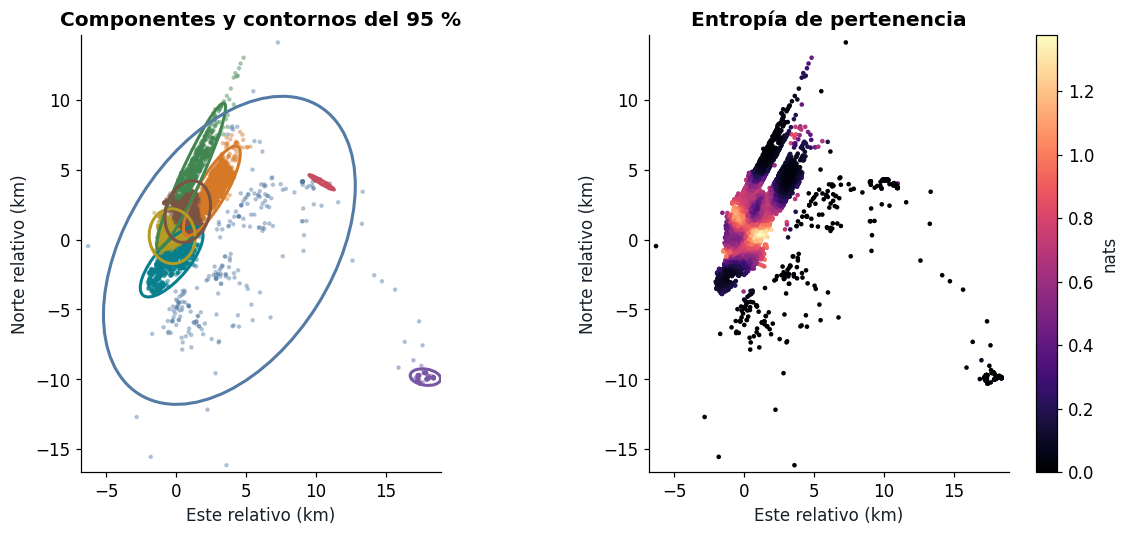

Punto lejano: mayor responsabilidad 1.0
Punto lejano: log-densidad -585.5365994835097


In [6]:
responsibilities = best.predict_proba(X)
entropy = -(responsibilities*np.log(np.maximum(responsibilities,1e-300))).sum(axis=1)
assert np.allclose(responsibilities.sum(axis=1),1)
assert np.isclose(best.weights_.sum(),1)
fig, axes = plt.subplots(1,2,figsize=(11,5))
axes[0].scatter(*X.T,c=np.asarray(COLORS)[best.predict(X)],s=4,alpha=.35)
ellipses(axes[0],best)
points = axes[1].scatter(*X.T,c=entropy,cmap='magma',s=4)
for ax,title in zip(axes,['Componentes y contornos del 95 %','Entropía de pertenencia']):
    spatial_axes(ax,X,title)
fig.colorbar(points,ax=axes[1],label='nats'); fig.tight_layout()
savefig(fig,'05_gmm_espacial')
far = np.array([[X[:,0].max()+100, X[:,1].max()+100]])
print('Punto lejano: mayor responsabilidad',best.predict_proba(far).max())
print('Punto lejano: log-densidad',best.score_samples(far)[0])

## 5. Congelar, después evaluar
La celda siguiente se ejecuta al final. El test mide transferencia temporal a los meses reservados;
no es una estimación universal de la movilidad futura. No se vuelve a seleccionar usando su resultado.

In [7]:
frozen = dict(k=int(winner.k), covariance=str(winner.covariance), seed=42)
test = load_data('test')
Xt = test[['x_km','y_km']].to_numpy()
test['log_density'] = best.score_samples(Xt)
monthly = test.groupby(test.pickup_datetime.dt.month).log_density.agg(['mean','std','count']).reset_index()
display(monthly)
save_table(monthly,'gmm_test_temporal')
print('Configuración congelada:',frozen)
print('Promedio temporal:',test.log_density.mean())

,pickup_datetime,mean,std,count
0,10,-3.697354,1.222333,2615
1,11,-3.733753,1.262606,2358
2,12,-3.743670,1.274392,2338


Configuración congelada: {'k': 8, 'covariance': 'full', 'seed': 42}
Promedio temporal: -3.723905395151227


### Para resolver

Ticket: 1) ¿Qué optimiza EM? 2) ¿Qué significa una responsabilidad de 0.55? 3) ¿Qué no demuestra el BIC?

**Mi respuesta y evidencia (Ticket de Salida · Lunes):**

1. **¿Qué optimiza EM?**
   El algoritmo EM optimiza localmente la log-verosimilitud marginal observada $\ell(\theta) = \sum_{i=1}^n \log \left(\sum_{k=1}^K \pi_k \phi(x_i; \mu_k, \Sigma_k)\right)$. Como el logaritmo de una suma es intratable directamente, EM optimiza de forma alternada la cota inferior de evidencia (ELBO): $\mathcal{F}(q, \theta) = \mathbb{E}_q[\log p(X, Z \mid \theta)] + \mathcal{H}(q)$. En el paso E, se fija $q(Z) = p(Z \mid X, \theta^{(t)})$, haciendo que la divergencia $\mathrm{KL}(q \parallel p) = 0$ y por ende $\mathcal{F}(q, \theta^{(t)}) = \ell(\theta^{(t)})$. En el paso M, se maximiza $\mathcal{F}(q, \theta)$ respecto a $\theta$. Garantiza que $\ell(\theta^{(t+1)}) \ge \ell(\theta^{(t)})$, convergiendo a un punto estacionario (máximo local o punto de silla), pero **no garantiza encontrar el máximo global ni unicidad de parámetros**.

2. **¿Qué significa una responsabilidad de 0.55?**
   $r_{ik} = 0.55$ representa la probabilidad condicional a posteriori $P(z_i = k \mid x_i, \theta)$ de que la observación $x_i$ haya sido generada por la componente normal $k$, dados los parámetros del modelo. Esto evidencia una **alta ambigüedad de pertenencia** (especialmente en $K=2$, donde está apenas por encima del azar $0.5$).
   *Distinción crítica*: **Responsabilidad condicional no equivale a densidad ni a normalidad**. Un punto muy lejano en la periferia rural puede tener $r_{ik} = 0.55$ (o incluso $0.99$ si es la componente menos lejana), mientras que su densidad de probabilidad absoluta $f(x_i)$ es prácticamente cero ($10^{-50}\text{ km}^{-2}$).

3. **¿Qué no demuestra el BIC?**
   El criterio de información bayesiano ($\mathrm{BIC} = -2\ell(\widehat{\theta}) + p\log n$) es una métrica de parsimonia para ordenar modelos candidatos. **No demuestra**:
   - Que el modelo seleccionado sea el verdadero proceso generador de los datos en la ciudad.
   - Que existan ontológicamente $K$ grupos, barrios o zonas operativas reales.
   - Rendimiento predictivo o validez operativa fuera de la muestra, pues sus justificaciones asintóticas asumen observaciones independientes e idénticamente distribuidas (i.i.d.), ignorando la autocorrelación espacial y estacional de los viajes.

- **Unidades:** Responsabilidad adimensional en $[0, 1]$; log-verosimilitud y BIC adimensionales.
- **Limitación:** Las componentes estimadas dependen del soporte y tamaño de la muestra de desarrollo analizada.

## Fuentes y reproducción
- Microcurrículo y guía docente ML2, sesiones 19–24; adaptación del cuaderno histórico del profesor.
- [GMM](https://scikit-learn.org/stable/modules/mixture.html), [KDE](https://scikit-learn.org/stable/modules/density.html), [clustering](https://scikit-learn.org/stable/modules/clustering.html).
- Dataset suministrado por el docente; ver `datasets/semana-08/README.md` y `manifest.json`.
- Dependencias fijadas en `requirements-week8.txt`. Inicie el kernel en una carpeta del paquete.